# Adversarial Reprogramming of Growing Neural Cellular Automata

This notebook contains code to reproduce experiments and figures regarding Growing CAs for the "Adversarial Reprogramming of Neural Cellular Automata" article.

Copyright 2020 Google LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.

# Common setup

In [1]:
# Colab GPU check

import torch
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")

Tesla T4


In [2]:
# Use legacy keras - because code uses keras v2 and not v3

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [3]:
#@title Imports and Notebook Utilities
%tensorflow_version 2.x

import os
import io
import PIL.Image, PIL.ImageDraw
import base64
import zipfile
import json
import requests
import numpy as np
import matplotlib.pylab as pl
import glob

import tensorflow as tf
# from tensorflow.keras import mixed_precision
# mixed_precision.set_global_policy('mixed_float16')

from IPython.display import Image, HTML, clear_output
import tqdm

import os
os.environ['FFMPEG_BINARY'] = 'ffmpeg'
import moviepy.editor as mvp
from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter
clear_output()

def np2pil(a):
  if a.dtype in [np.float32, np.float64]:
    a = np.uint8(np.clip(a, 0, 1)*255)
  return PIL.Image.fromarray(a)

def imwrite(f, a, fmt=None):
  a = np.asarray(a)
  if isinstance(f, str):
    fmt = f.rsplit('.', 1)[-1].lower()
    if fmt == 'jpg':
      fmt = 'jpeg'
    f = open(f, 'wb')
  np2pil(a).save(f, fmt, quality=95)

def imencode(a, fmt='jpeg'):
  a = np.asarray(a)
  if len(a.shape) == 3 and a.shape[-1] == 4:
    fmt = 'png'
  f = io.BytesIO()
  imwrite(f, a, fmt)
  return f.getvalue()

def im2url(a, fmt='jpeg'):
  encoded = imencode(a, fmt)
  base64_byte_string = base64.b64encode(encoded).decode('ascii')
  return 'data:image/' + fmt.upper() + ';base64,' + base64_byte_string

def imshow(a, fmt='jpeg'):
  display(Image(data=imencode(a, fmt)))

def tile2d(a, w=None):
  a = np.asarray(a)
  if w is None:
    w = int(np.ceil(np.sqrt(len(a))))
  th, tw = a.shape[1:3]
  pad = (w-len(a))%w
  a = np.pad(a, [(0, pad)]+[(0, 0)]*(a.ndim-1), 'constant')
  h = len(a)//w
  a = a.reshape([h, w]+list(a.shape[1:]))
  a = np.rollaxis(a, 2, 1).reshape([th*h, tw*w]+list(a.shape[4:]))
  return a

def zoom(img, scale=4):
  img = np.repeat(img, scale, 0)
  img = np.repeat(img, scale, 1)
  return img

class VideoWriter:
  def __init__(self, filename, fps=30.0, **kw):
    self.writer = None
    self.params = dict(filename=filename, fps=fps, **kw)

  def add(self, img):
    img = np.asarray(img)
    if self.writer is None:
      h, w = img.shape[:2]
      self.writer = FFMPEG_VideoWriter(size=(w, h), **self.params)
    if img.dtype in [np.float32, np.float64]:
      img = np.uint8(img.clip(0, 1)*255)
    if len(img.shape) == 2:
      img = np.repeat(img[..., None], 3, -1)
    self.writer.write_frame(img)

  def close(self):
    if self.writer:
      self.writer.close()

  def __enter__(self):
    return self

  def __exit__(self, *kw):
    self.close()

In [4]:
#@title Cellular Automata Parameters
CHANNEL_N = 16        # Number of CA state channels
TARGET_SIZE = 40
BATCH_SIZE = 8
POOL_SIZE = 1024
CELL_FIRE_RATE = 0.5

EXPERIMENT_TYPE = "Regenerating" #@param ["Persistent", "Regenerating"]
EXPERIMENT_MAP = {"Persistent":0, "Regenerating":1}
EXPERIMENT_N = EXPERIMENT_MAP[EXPERIMENT_TYPE]

DAMAGE_N = [0, 3][EXPERIMENT_N]  # Number of patterns to damage in a batch

In [5]:
#@title CA Model and Utilities
#@markdown This model doesn't have a bias in the last layer.
from tensorflow.keras.layers import Conv2D

def load_image(url, max_size=TARGET_SIZE):
  r = requests.get(url)
  img = PIL.Image.open(io.BytesIO(r.content))
  img.thumbnail((max_size, max_size), PIL.Image.LANCZOS)
  img = np.float32(img)/255.0
  # premultiply RGB by Alpha
  img[..., :3] *= img[..., 3:]
  return img

def to_rgba(x):
  return x[..., :4]

def to_alpha(x):
  return tf.clip_by_value(x[..., 3:4], 0.0, 1.0)

def to_rgb(x):
  # assume rgb premultiplied by alpha
  rgb, a = x[..., :3], to_alpha(x)
  return 1.0-a+rgb

def get_living_mask(x):
  alpha = x[:, :, :, 3:4]
  return tf.nn.max_pool2d(alpha, 3, [1, 1, 1, 1], 'SAME') > 0.1

def make_seed(size, n=1):
  x = np.zeros([n, size, size, CHANNEL_N], np.float32)
  x[:, size//2, size//2, 3:] = 1.0
  return x


class CAModel(tf.keras.Model):

  def __init__(self, channel_n=CHANNEL_N, fire_rate=CELL_FIRE_RATE):
    super().__init__()
    self.channel_n = channel_n
    self.fire_rate = fire_rate

    self.dmodel = tf.keras.Sequential([
          Conv2D(128, 1, activation=tf.nn.relu),
          Conv2D(self.channel_n, 1, activation=None,
              kernel_initializer=tf.zeros_initializer),
    ])

    self(tf.zeros([1, 3, 3, channel_n]))  # dummy call to build the model

  @tf.function
  def perceive(self, x, angle=0.0):
    identify = np.float32([0, 1, 0])
    identify = np.outer(identify, identify)
    dx = np.outer([1, 2, 1], [-1, 0, 1]) / 8.0  # Sobel filter
    dy = dx.T
    c, s = tf.cos(angle), tf.sin(angle)
    kernel = tf.stack([identify, c*dx-s*dy, s*dx+c*dy], -1)[:, :, None, :]
    kernel = tf.repeat(kernel, self.channel_n, 2)
    y = tf.nn.depthwise_conv2d(x, kernel, [1, 1, 1, 1], 'SAME')
    return y

  @tf.function
  def call(self, x, fire_rate=None, angle=0.0, step_size=1.0):
    pre_life_mask = get_living_mask(x)

    y = self.perceive(x, angle)
    dx = self.dmodel(y)*step_size
    if fire_rate is None:
      fire_rate = self.fire_rate
    update_mask = tf.random.uniform(tf.shape(x[:, :, :, :1])) <= fire_rate
    x += dx * tf.cast(update_mask, tf.float32)

    post_life_mask = get_living_mask(x)
    life_mask = pre_life_mask & post_life_mask
    return x * tf.cast(life_mask, tf.float32)


CAModel().dmodel.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (1, 3, 3, 128)            6272      
                                                                 
 conv2d_1 (Conv2D)           (1, 3, 3, 16)             2064      
                                                                 
Total params: 8336 (32.56 KB)
Trainable params: 8336 (32.56 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [6]:
#@title Train Utilities (SamplePool, Model Export, Damage)
from google.protobuf.json_format import MessageToDict
from tensorflow.python.framework import convert_to_constants

class SamplePool:
  def __init__(self, *, _parent=None, _parent_idx=None, **slots):
    self._parent = _parent
    self._parent_idx = _parent_idx
    self._slot_names = slots.keys()
    self._size = None
    for k, v in slots.items():
      if self._size is None:
        self._size = len(v)
      assert self._size == len(v)
      setattr(self, k, np.asarray(v))

  def sample(self, n):
    idx = np.random.choice(self._size, n, False)
    batch = {k: getattr(self, k)[idx] for k in self._slot_names}
    batch = SamplePool(**batch, _parent=self, _parent_idx=idx)
    return batch

  def commit(self):
    for k in self._slot_names:
      getattr(self._parent, k)[self._parent_idx] = getattr(self, k)

@tf.function
def make_circle_masks(n, h, w):
  x = tf.linspace(-1.0, 1.0, w)[None, None, :]
  y = tf.linspace(-1.0, 1.0, h)[None, :, None]
  center = tf.random.uniform([2, n, 1, 1], -0.5, 0.5)
  r = tf.random.uniform([n, 1, 1], 0.1, 0.4)
  x, y = (x-center[0])/r, (y-center[1])/r
  mask = tf.cast(x*x+y*y < 1.0, tf.float32)
  return mask

def export_model(ca, base_fn):
  ca.save_weights(base_fn)

  cf = ca.call.get_concrete_function(
      x=tf.TensorSpec([None, None, None, CHANNEL_N]),
      fire_rate=tf.constant(0.5),
      angle=tf.constant(0.0),
      step_size=tf.constant(1.0))
  cf = convert_to_constants.convert_variables_to_constants_v2(cf)
  graph_def = cf.graph.as_graph_def()
  graph_json = MessageToDict(graph_def)
  graph_json['versions'] = dict(producer='1.14', minConsumer='1.14')
  model_json = {
      'format': 'graph-model',
      'modelTopology': graph_json,
      'weightsManifest': [],
  }
  with open(base_fn+'.json', 'w') as f:
    json.dump(model_json, f)

def generate_pool_figures(pool, step_i):
  tiled_pool = tile2d(to_rgb(pool.x[:49]))
  fade = np.linspace(1.0, 0.0, 72)
  ones = np.ones(72)
  tiled_pool[:, :72] += (-tiled_pool[:, :72] + ones[None, :, None]) * fade[None, :, None]
  tiled_pool[:, -72:] += (-tiled_pool[:, -72:] + ones[None, :, None]) * fade[None, ::-1, None]
  tiled_pool[:72, :] += (-tiled_pool[:72, :] + ones[:, None, None]) * fade[:, None, None]
  tiled_pool[-72:, :] += (-tiled_pool[-72:, :] + ones[:, None, None]) * fade[::-1, None, None]
  imwrite('train_log/%04d_pool.jpg'%step_i, tiled_pool)

def visualize_batch(x0, x, step_i):
  vis0 = np.hstack(to_rgb(x0).numpy())
  vis1 = np.hstack(to_rgb(x).numpy())
  vis = np.vstack([vis0, vis1])
  imwrite('train_log/batches_%04d.jpg'%step_i, vis)
  print('batch (before/after):')
  imshow(vis)

def plot_loss(loss_log):
  pl.figure(figsize=(10, 4))
  pl.title('Loss history (log10)')
  pl.plot(np.log10(loss_log), '.', alpha=0.1)
  pl.show()


In [7]:
!wget -O models.zip 'https://github.com/google-research/self-organising-systems/blob/master/assets/growing_ca/models.zip?raw=true'
!unzip -oq models.zip

# available pretrained emoji are:
#EMOJI = '🦎😀💥👁🐠🦋🐞🕸🥨🎄'

def get_model(emoji='🦎', fire_rate=0.5, use_pool=1, damage_n=3, run=0,
              prefix='models/', output='model'):
  path = prefix
  assert fire_rate in [0.5, 1.0]
  if fire_rate==0.5:
    path += 'use_sample_pool_%d damage_n_%d '%(use_pool, damage_n)
  elif fire_rate==1.0:
    path += 'fire_rate_1.0 '
  code = hex(ord(emoji))[2:].upper()
  path += 'target_emoji_%s run_index_%d/08000'%(code, run)
  assert output in ['model', 'json']
  if output == 'model':
    ca = CAModel(channel_n=16, fire_rate=fire_rate)
    ca.load_weights(path)
    return ca
  elif output == 'json':
    return open(path+'.json', 'r').read()

def get_local_model(path, output='model'):
  assert output in ['model', 'json']
  if output == 'model':
    ca = CAModel(channel_n=16)
    ca.load_weights(path)
    return ca
  elif output == 'json':
    return open(path+'.json', 'r').read()


--2026-06-13 18:31:51--  https://github.com/google-research/self-organising-systems/blob/master/assets/growing_ca/models.zip?raw=true
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/google-research/self-organising-systems/raw/refs/heads/master/assets/growing_ca/models.zip [following]
--2026-06-13 18:31:51--  https://github.com/google-research/self-organising-systems/raw/refs/heads/master/assets/growing_ca/models.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google-research/self-organising-systems/refs/heads/master/assets/growing_ca/models.zip [following]
--2026-06-13 18:31:52--  https://raw.githubusercontent.com/google-research/self-organising-systems/refs/heads/master/assets/growing_ca/models.zip
Resolving raw.githubusercontent.com (raw.gi

## CA Targets

In [8]:
!wget -O growing_ca_target_images.zip 'https://github.com/google-research/self-organising-systems/blob/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip?raw=true'
!unzip -oq "growing_ca_target_images.zip" -d "target_pics"
!ls target_pics/

--2026-06-13 18:31:53--  https://github.com/google-research/self-organising-systems/blob/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip?raw=true
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/google-research/self-organising-systems/raw/refs/heads/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip [following]
--2026-06-13 18:31:53--  https://github.com/google-research/self-organising-systems/raw/refs/heads/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google-research/self-organising-systems/refs/heads/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip [following]
--2026-06-13 18:31:53--  https://raw.githubus

In [9]:
# If you want a new picture, modify it with either:
# - https://pixlr.com/
# - https://www.piskelapp.com/
def load_image_from_file(fp, max_size=TARGET_SIZE):
  img = PIL.Image.open(fp)
  img.thumbnail((max_size, max_size), PIL.Image.LANCZOS)
  img = np.float32(img)/255.0
  # premultiply RGB by Alpha
  img[..., :3] *= img[..., 3:]
  return img

pic_prefix = "target_pics/"
lizard_no_tail_fp = pic_prefix + "lizard_no_tail.png"
lizard_no_leg_fp = pic_prefix + "lizard_no_leg.png"
lizard_no_head_fp = pic_prefix + "lizard_no_head.png"
lizard_no_arm_fp = pic_prefix + "lizard_no_arm.png"
lizard_red_fp = pic_prefix + "lizard_red.png"
lizard_blue_fp = pic_prefix + "lizard_blue.png"
target_map = {
    "liz_no_tail": lizard_no_tail_fp,
    "lizard_no_leg": lizard_no_leg_fp,
    "lizard_no_head": lizard_no_head_fp,
    "lizard_no_arm": lizard_no_arm_fp,
    "lizard_red": lizard_red_fp,
    "lizard_blue": lizard_blue_fp}

lizard_complete_fp = pic_prefix + "lizard_complete.png"

#butterfly_all_orange_fp = pic_prefix + "butterfly_all_orange.png"
#butterfly_left_orange_fp = pic_prefix + "butterfly_left_orange.png"


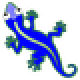

In [10]:
target_label = 'lizard_blue' #@param ["liz_no_tail", "liz_no_leg", "liz_no_head", "lizard_no_arm", "lizard_red", "lizard_blue"]

target_img = load_image_from_file(target_map[target_label])
imshow(zoom(to_rgb(target_img), 2), fmt='png')

## Gaussian starter matrix + gradient optimizer

This notebook trains the attack (mutation) matrix with the gradient/backprop optimizer, initialised from a **symmetric Gaussian-noise matrix** (entries ~ N(0, 1)) rather than the identity. Phase 1 runs the training; the results section then reports the loss curve and the image grown from the empty seed under the learned matrix.

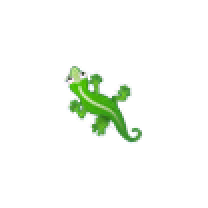

loss0 (empty seed): 0.021845243871212006


In [11]:
#@title Shared setup & helpers (seed, NCA, render) {vertical-output: true}
import time

# ---- target & seed (shared by the gradient phase) ----
TARGET_PADDING = 32
p = TARGET_PADDING
pad_target = tf.pad(target_img, [(p, p), (p, p), (0, 0)])
h, w = pad_target.shape[:2]

seed = np.zeros([h, w, CHANNEL_N], np.float32)
seed[h // 2, w // 2, 3:] = 1.0

def loss_f(x):
    return tf.reduce_mean(tf.square(to_rgba(x) - pad_target), [-2, -3, -1])

target_emoji = '🦎'
ca = get_model(emoji=target_emoji)

# Grow a healthy lizard once; used as a second seed source and for the morph demo.
x0_seed = seed[None, ...]
for _ in tf.range(200):
    x0_seed = ca(x0_seed)
imshow(zoom(to_rgb(x0_seed[0]), 2), fmt='png')

loss0 = float(loss_f(seed).numpy())
print('loss0 (empty seed):', loss0)

def fresh_pool():
    elems = np.concatenate([
        np.repeat(seed[None, ...], POOL_SIZE // 2, 0),
        np.repeat(x0_seed,         POOL_SIZE // 2, 0)], 0)
    return SamplePool(x=elems)

def var_to_sym(var):
    """tf 16x16 Variable -> symmetric matrix, matching the backprop train step."""
    m_upper = tf.linalg.band_part(var, 0, -1)
    return (m_upper + tf.transpose(m_upper)
            - tf.linalg.tensor_diag(tf.linalg.diag_part(var))).numpy()

# ---- growing / evaluating a single matrix for visualisation & final metrics ----
RENDER_STEPS = 120   # NCA steps used to grow an image for display
EVAL_STEPS   = 96    # NCA steps used for the "grown-image loss" metric
EVAL_RUNS    = 4     # stochastic renders averaged for that metric

def render_growth(M, x_start, steps, capture=()):
    """Grow from x_start applying mutation M each NCA step. Returns (final, frames).
    Same per-step recipe as training: living-mask, mutation, clip +/-3, re-mask, NCA."""
    M_t = tf.constant(np.asarray(M, np.float32))
    x = tf.constant(np.asarray(x_start, np.float32)[None])
    cap = set(capture)
    frames = []
    for i in range(steps + 1):
        if i in cap:
            frames.append((i, to_rgb(x[0]).numpy()))
        lm = tf.cast(get_living_mask(x), tf.float32)
        x = tf.einsum('bhwc,cd->bhwd', x, M_t)
        x = tf.clip_by_value(x, -3., 3.) * lm
        x = ca(x)
    return x, frames

def grown_image_loss(M, steps=EVAL_STEPS, runs=EVAL_RUNS):
    """Mean +/- std loss of the image grown from the empty seed (NCA is stochastic)."""
    vals = [float(loss_f(render_growth(M, seed, steps)[0])[0]) for _ in range(runs)]
    return float(np.mean(vals)), float(np.std(vals))

!mkdir -p train_log && rm -f train_log/*

## Gradient training from a Gaussian starter matrix

Train the symmetric mutation matrix by backprop — the original gradient approach — but **starting from a symmetric Gaussian-noise matrix** (entries ~ N(0, 1)) instead of the identity. We keep the final matrix (`M_grad`) and the full per-step loss history (`grad_loss_log`) for the results plots below.

> This runs the full backprop training (8000 steps) and is the slow part of the notebook.

batch (before/after):


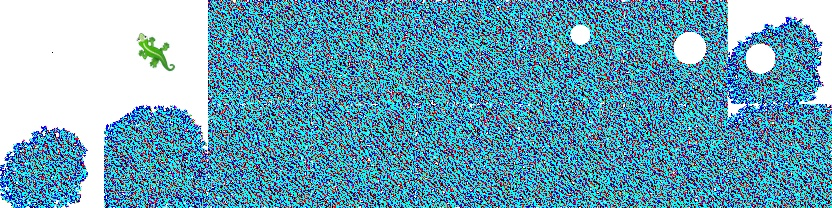

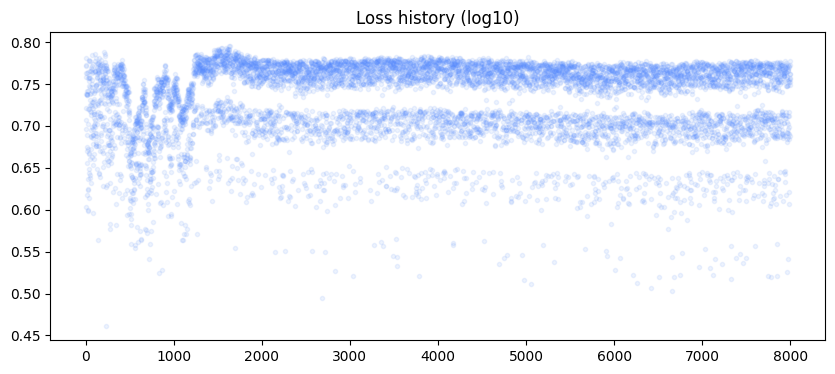

 step: 8001, log10(loss): 0.757
Gradient phase done. best log10(loss): 0.461


In [12]:
#@title Phase 1: gradient training loop {vertical-output: true}
np.random.seed(42)
_g = np.random.randn(CHANNEL_N, CHANNEL_N).astype(np.float32)
grad_mut = tf.Variable((_g + _g.T) / 2)

grad_lr = 2e-3
grad_sched = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
    [2000], [grad_lr, grad_lr * 0.1])
grad_trainer = tf.keras.optimizers.Adam(grad_sched)
grad_pool = fresh_pool()
grad_loss_log = []

@tf.function
def grad_train_step(x):
    iter_n = tf.random.uniform([], 64, 96, tf.int32)
    with tf.GradientTape() as g:
        m_upper = tf.linalg.band_part(grad_mut, 0, -1)
        M = (m_upper + tf.transpose(m_upper)
             - tf.linalg.tensor_diag(tf.linalg.diag_part(grad_mut)))
        for _ in tf.range(iter_n):
            lm = tf.cast(get_living_mask(x), tf.float32)
            x = tf.einsum('bhwc,cd->bhwd', x, M)
            x = tf.clip_by_value(x, -3., 3.) * lm
            x = ca(x)
        loss = tf.reduce_mean(loss_f(x))
    grads = g.gradient(loss, [grad_mut])
    grads = [gr / (tf.norm(gr) + 1e-8) for gr in grads]
    grad_trainer.apply_gradients(zip(grads, [grad_mut]))
    return x, loss

for i in range(8000 + 1):
    batch = grad_pool.sample(BATCH_SIZE)
    x0 = batch.x
    x0 = x0[loss_f(x0).numpy().argsort()[::-1]]
    x0[:1] = seed
    x0[1:2] = x0_seed[0]
    if DAMAGE_N:
        damage = 1.0 - make_circle_masks(DAMAGE_N, h, w).numpy()[..., None]
        x0[-DAMAGE_N:] *= damage

    x, loss = grad_train_step(x0)
    batch.x[:] = x
    batch.commit()

    step_i = len(grad_loss_log)
    grad_loss_log.append(float(loss))
    if step_i % 100 == 0:
        clear_output()
        visualize_batch(x0, x, step_i)
        plot_loss(grad_loss_log)
    print('\r step: %d, log10(loss): %.3f' % (len(grad_loss_log), np.log10(loss)), end='')

M_grad = var_to_sym(grad_mut)
print('\nGradient phase done. best log10(loss): %.3f' % np.log10(min(grad_loss_log)))

## Results

Loss curve over training, the image grown from the empty seed under the learned matrix, a growth strip, and the same mutation applied to an already-grown lizard.

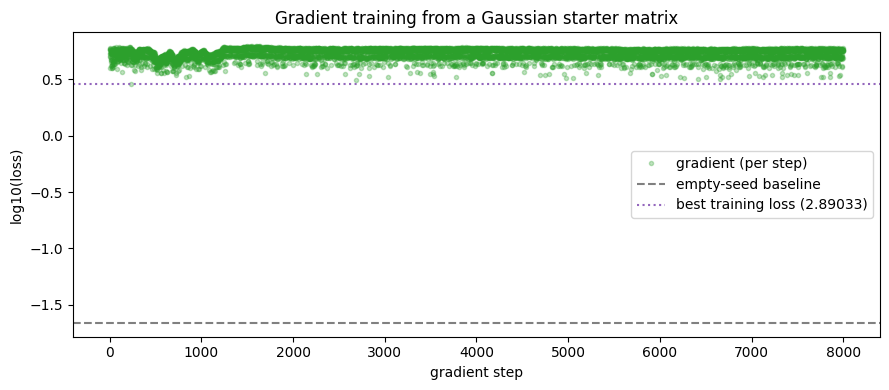

best training loss : 2.890328
final training loss: 5.710154
grown-image loss   : 4.550461 +/- 0.201547
empty-seed loss0   : 0.021845
Target | grown from empty seed


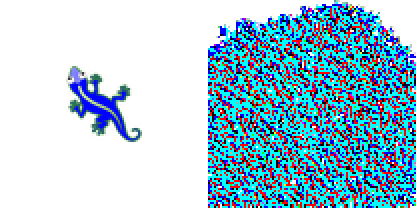

growth (steps [0, 20, 40, 60, 80, 100, 120]):


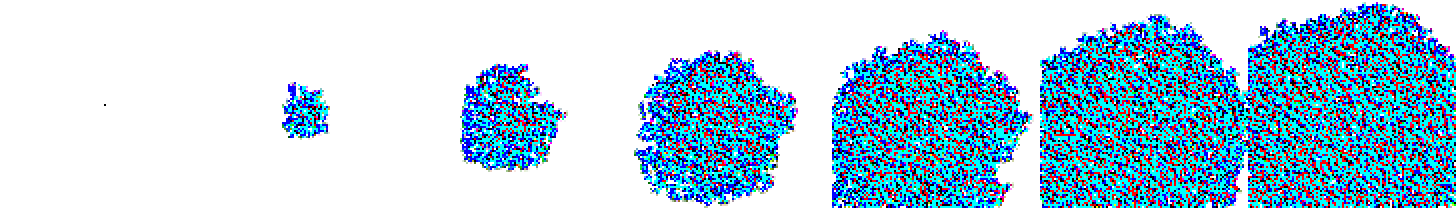

Healthy | after mutation (applied to a grown lizard)


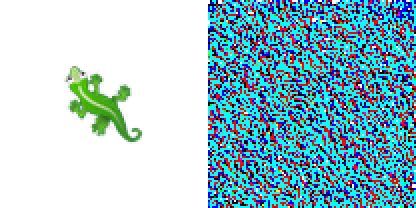

In [14]:
# ---- (a) training loss curve ----
pl.figure(figsize=(9, 4))
pl.plot(np.log10(grad_loss_log), '.', alpha=.3, color='tab:green',
        label='gradient (per step)')
pl.axhline(np.log10(loss0), ls='--', c='gray', label='empty-seed baseline')
pl.axhline(np.log10(min(grad_loss_log)), ls=':', c='tab:purple',
           label=f'best training loss ({min(grad_loss_log):.5f})')
pl.title('Gradient training from a Gaussian starter matrix')
pl.xlabel('gradient step'); pl.ylabel('log10(loss)')
pl.legend(); pl.tight_layout(); pl.show()

# ---- (b) metrics (grown-from-seed loss is the deployment metric) ----
gm, gs = grown_image_loss(M_grad)
print('=' * 60)
print(f"best training loss : {min(grad_loss_log):.6f}")
print(f"final training loss: {grad_loss_log[-1]:.6f}")
print(f"grown-image loss   : {gm:.6f} +/- {gs:.6f}")
print(f"empty-seed loss0   : {loss0:.6f}")
print('=' * 60)

# ---- (c) target vs grown image, plus a growth strip ----
CAP = [0, 20, 40, 60, 80, 100, RENDER_STEPS]
fx, frames = render_growth(M_grad, seed, RENDER_STEPS, CAP)
pair = np.hstack([to_rgb(pad_target).numpy(), to_rgb(fx[0]).numpy()])
print('Target | grown from empty seed')
imshow(zoom(pair, 2), fmt='png')
print(f'growth (steps {CAP}):')
imshow(zoom(np.hstack([f for _, f in frames]), 2), fmt='png')

# ---- (d) mutation applied to an already-grown healthy lizard ----
morph = np.hstack([
    to_rgb(x0_seed[0]).numpy(),
    to_rgb(render_growth(M_grad, x0_seed[0], RENDER_STEPS)[0][0]).numpy()])
print('Healthy | after mutation (applied to a grown lizard)')
imshow(zoom(morph, 2), fmt='png')